## Collecting references for network-wide traffic flow prediction literature review

Paper title: "Data-driven network-wide traffic flow modelling: Are we ready for real-world applications?"

Authors: Laura Gualda, Mohamed Abouelela, Ramandeep Singh, Constantinos Antoniou

Using https://github.com/vishalmhjn/scopus_caller

In [21]:
import scopuscaller as sc
import pandas as pd
import numpy as np
from itertools import product
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')

import time
import os

from dotenv import load_dotenv

In [ ]:
load_dotenv('../.envrc')
api_key = os.getenv("SCOPUS_API_KEY")

In [ ]:
def fetch_and_combine_titles(api_key, keyword_combinations, year=2025, 
                             checkpoint_file='checkpoint.pkl', 
                             delay=1.0, resume=True):
    """
    Fetch titles for multiple keyword combinations, add a column 'source' to identify them and combine all into one DataFrame.

    Input should have the form:
        keyword_combinations = [
            (["city-wide", "traffic prediction"], "city-wide + traffic prediction"),
            (["city-wide", "traffic flow"], "city-wide + traffic flow"),
            (["city-wide", "traffic volume"], "city-wide + traffic volume")
        ]
    """
    dfs = []
    start_idx = 0
    
    # Load checkpoint if resuming
    if resume and os.path.exists(checkpoint_file):
        checkpoint = pd.read_pickle(checkpoint_file)
        dfs = checkpoint['dfs']
        start_idx = checkpoint['last_idx'] + 1
        print(f"Resuming from combination {start_idx}/{len(keyword_combinations)}")
    
    # Process combinations
    for idx in range(start_idx, len(keyword_combinations)):
        keywords, source_label = keyword_combinations[idx]
        
        try:
            print(f"[{idx+1}/{len(keyword_combinations)}] Extracting {keywords}...")
            df = sc.get_titles(api_key, keywords, year)
            df['source'] = source_label
            dfs.append(df)
            
            # Save checkpoint every 10 iterations
            if (idx + 1) % 10 == 0:
                pd.to_pickle({'dfs': dfs, 'last_idx': idx}, checkpoint_file)
                print(f"Checkpoint saved at {idx+1}")
            
            # Rate limiting
            time.sleep(delay)
            
        except Exception as e:
            print(f"ERROR on {keywords}: {e}")
            # Save checkpoint on error
            pd.to_pickle({'dfs': dfs, 'last_idx': idx - 1}, checkpoint_file)
            print(f"Checkpoint saved. Resume later to continue from combination {idx+1}")
            raise
    
    # Combine all dataframes
    combined_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    
    # Clean up checkpoint file
    if os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)
    
    print(f"Completed! Fetched {len(combined_df)} total results from {len(dfs)} combinations.")
    return combined_df

## 1. Fetching combinations of keywords

### Combination of relevant keywords

- At first we want to include ML terms, but in reality it narrowed down the results. To be effective we would have to add a wide range of ML algorithms. The filtering for data-driven papers will be done manually on step 2.
- Urban was also included as spatial term, but it resulted more than a 1500 papers (in contrast with 400), and after a brief scan I noticed that many were not network-wide, just in the urban context.
- Including 2026 as limit just to see if there are any papers accepted in 2025 but published on issues dated of 2026.

In [ ]:
spatial_terms = ["city-wide", "citywide", "city-scale", "city-level", "network-wide", "networkwide"] # Include city wide and network wide
traffic_terms = ["traffic flow", "traffic volume"]
task_terms = ["", "predict*", "estimat*", "forecast*", "model*"]
#ml_terms = ["data-driven", "machine learning", "deep learning", "neural networks", "transformers", "transfer learning"]

In [ ]:
combinations = [
    ([base] + [traffic] + [task], f"{base}_{traffic}_{task}")
    for base, traffic, task in product(spatial_terms, traffic_terms, task_terms)
]
len(combinations)

In [ ]:
result = fetch_and_combine_titles(api_key, combinations, year=2026)

In [ ]:
len(result) # Retrieved publications, before removing duplicates

In [ ]:
result['is_duplicate'] = result.duplicated(subset=['doi'], keep=False)
result_dedup = (
    result.groupby('doi', as_index=False)
        .agg({col: 'first' if col != 'source' else '+ '.join for col in result.columns})
    )
len(result_dedup) # Removing duplicates based on DOI

In [ ]:
result_dedup.to_excel('./outputs/scopus_all_13012026.xlsx', index=False)

## 2. Aggregated statistics

### 2.1 Dataset before filtering

In [ ]:
result_dedup['date'] = pd.to_datetime(result_dedup['date'])
result_dedup['year'] = result_dedup['date'].dt.year
pub_counts = result_dedup['year'].value_counts().sort_index()

# Create area plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=pub_counts.index, y=pub_counts.values, linewidth=2)
plt.fill_between(pub_counts.index, pub_counts.values, alpha=0.3)
plt.xlabel('Year')
plt.ylabel('Number of publications')
plt.title('Retrieved publications using selected keywords')
plt.tight_layout()
plt.show()

In [ ]:
top_publishers = (result_dedup.groupby(['publisher', 'year'])
                    .size()
                    .unstack(fill_value=0)
                    .sort_values(by=2025, ascending=False))

top_publishers

### 2.2 Dataset after filtering

In [16]:
filtered_result = pd.read_excel('./outputs/Literature_current_version_2026.xlsx', sheet_name='5-Filtered + manually added')
filtered_result.head()

,Source,Author,Title,Year,Publisher
0,systematic,Zhang et al. (2025),Multi-step citywide traffic flow forecasting b...,2025,Engineering Applications of Artificial Intelli...
1,systematic,Zhang and Li (2025),A data-fusion spatiotemporal matrix factorizat...,2025,Information Fusion
2,systematic,Sabzekar et al. (2025),Spatial Network-Wide Traffic Flow Imputation w...,2025,International Journal of Intelligent Transport...
3,systematic,Eisinga and Lorkowski (2025),Network-Wide Traffic Volume Estimation Based o...,2025,Transportation Research Record
4,systematic,Jia et al. (2025),i-CLTP: Integrated contrastive learning with t...,2025,Transportation Research Part C Emerging Techno...


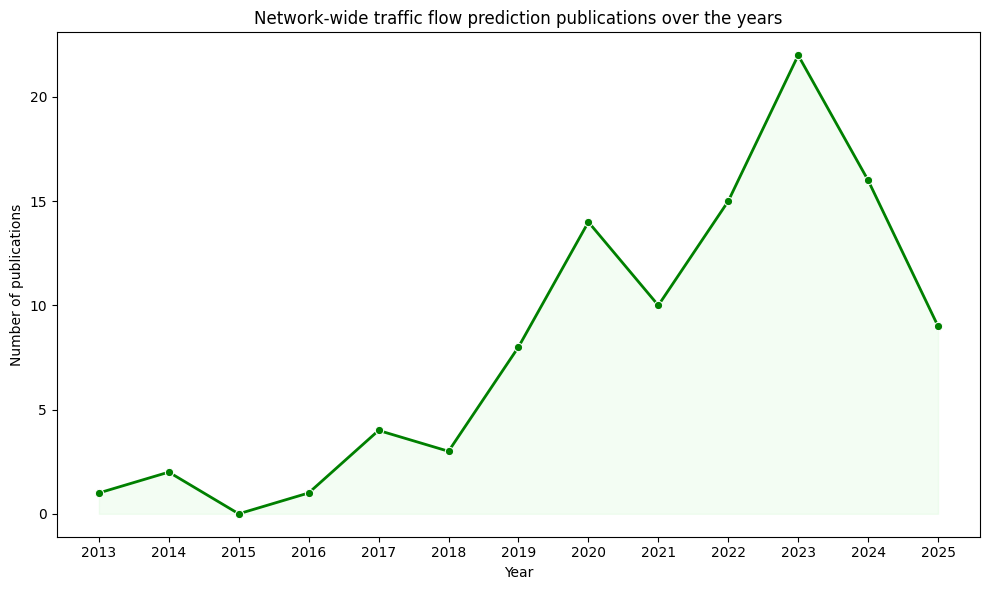

In [17]:
filtered_result['Year'] = filtered_result['Year'].astype(int)
pub_counts = filtered_result['Year'].value_counts().sort_index()

# Reindex to include all years from min to 2025
all_years = range(pub_counts.index.min(), 2026)  # 2026 to include 2025
pub_counts = pub_counts.reindex(all_years, fill_value=0)

# Create area plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=pub_counts.index, y=pub_counts.values, linewidth=2, marker='o',color='green')
plt.fill_between(pub_counts.index, pub_counts.values, alpha=0.1, color='lightgreen')
plt.xlabel('Year')
plt.ylabel('Number of publications')
plt.title('Network-wide traffic flow prediction publications over the years')
plt.xticks(range(pub_counts.index.min(), 2026, 1))  # Show every 2 years or use 1 for all years
plt.tight_layout()
plt.show()

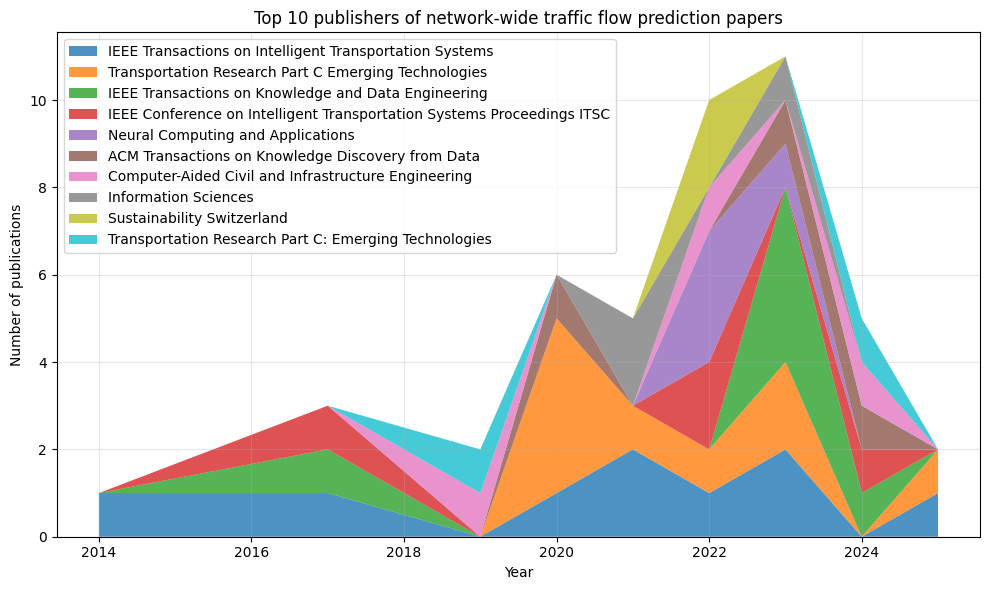

In [19]:
top_publishers = filtered_result['Publisher'].value_counts().head(10).index
filtered_result['Year'] = filtered_result['Year'].astype(int)

df_top = filtered_result[filtered_result['Publisher'].isin(top_publishers)]

pub_counts = df_top.groupby(['Year', 'Publisher']).size().unstack(fill_value=0)

pub_counts = pub_counts[pub_counts.sum().sort_values(ascending=False).index]

plt.figure(figsize=(10, 6))
plt.stackplot(pub_counts.index, 
              *[pub_counts[col] for col in pub_counts.columns],
              labels=pub_counts.columns,
              alpha=0.8)

plt.xlabel('Year')
plt.ylabel('Number of publications')
plt.title('Top 10 publishers of network-wide traffic flow prediction papers')
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Figures for publication

In [12]:
filepath = './outputs/Literature_current_version_2026.xlsx'
sheet_name = '9-Time series'

colors = ['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51', '#CCCCCC']
markers = ['o', 's', '^', 'D', 'v', 'p']
df1 = pd.read_excel(filepath, sheet_name)
df1.head()

,Reference,Journal,Year,Data-driven methods,Class,Conference
0,Hu et al. (2025),\nCommunications in Transportation Research,2025,Graph-based deep learning,Graph-based DL,0
1,Hammoumi et al. (2025)\t,International Conference on Models and Technol...,2025,Deep learning,Standard DL,1
2,Ali et al. (2025),"Chaos, Solitons & Fractals",2025,Graph-based deep learning,Graph-based DL,0
3,Zhang et al. (2025),Engineering Applications of Artificial Intelli...,2025,Deep learning,Standard DL,0
4,Zhang and Li (2025),Information Fusion,2025,"Optimisation, Statistics",Hybrid,0


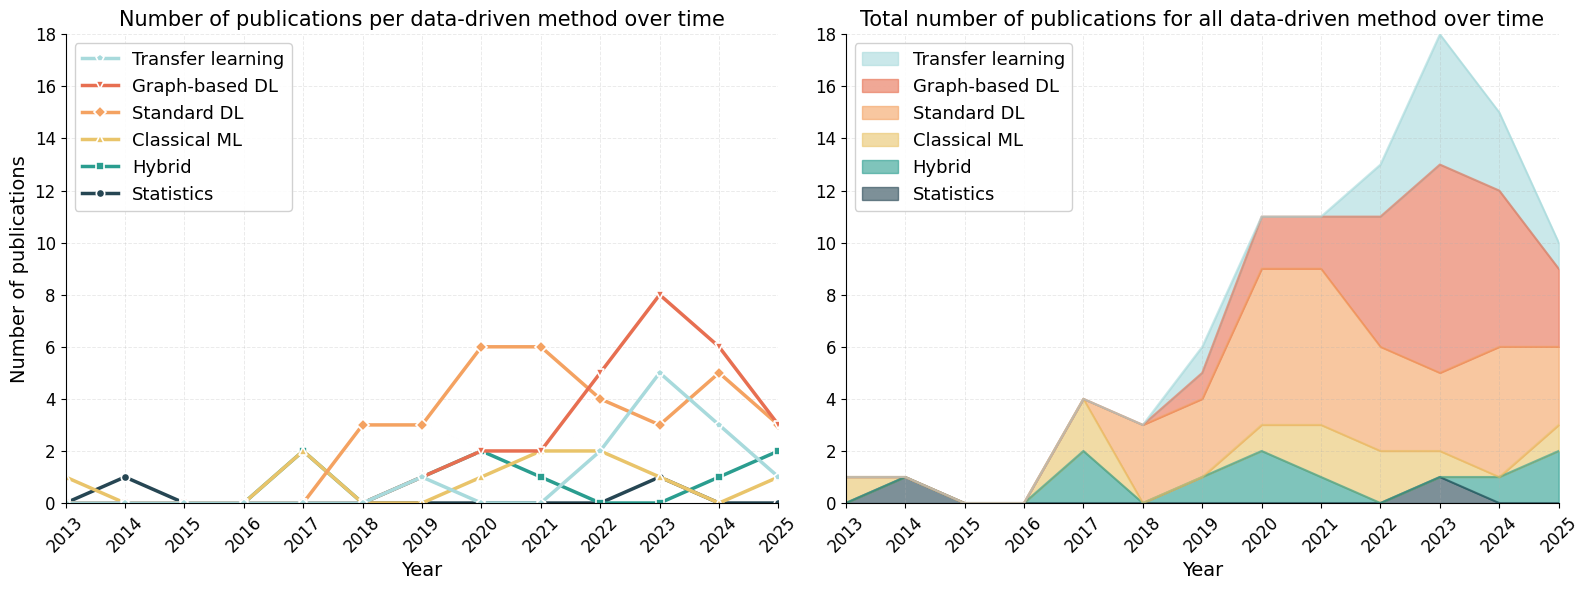

In [11]:
df_year_model = df1[['Year', 'Class', 'Reference']].groupby(['Year', 'Class']).count().reset_index()
df_pivot = df_year_model.pivot_table(index="Year", columns="Class", values="Reference", aggfunc="sum", fill_value=0)

all_years = np.arange(df_pivot.index.min(), df_pivot.index.max() + 1)
df_pivot = df_pivot.reindex(all_years, fill_value=0)

desired_order = ["Statistics", "Hybrid", "Classical ML", "Standard DL",  "Graph-based DL", "Transfer learning"]
df_pivot = df_pivot[desired_order]

max_value = df_pivot.sum(axis=1).max()

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(16, 6))

df_pivot.plot(kind="area", stacked=True, color=colors, alpha=0.6, ax=ax1)
ax1.set_xlabel("Year", fontsize=14)
#ax1.set_ylabel("Number of publications", fontsize=12)
ax1.set_title("Total number of publications for all data-driven method over time", fontsize=15)
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles[::-1], labels[::-1], loc="upper left", framealpha=0.9, fontsize=13)
ax1.set_xticks(all_years)
ax1.set_xticklabels(all_years, rotation=45, fontsize=12)
ax1.set_xlim(2013, 2025)
ax1.grid(alpha=0.25, linestyle='--', linewidth=0.7)
ax1.set_yticks(range(0, int(max_value) + 1, 2))
ax1.set_ylim(0, 18)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='y', labelsize=12)

categories = ["Statistics", "Hybrid", "Classical ML", "Standard DL",  "Graph-based DL", "Transfer learning"]
df_filtered = df_pivot[categories]
markers = ['o', 's', '^', 'D', 'v', 'p']

for col, color, marker in zip(categories, colors, markers):
    ax2.plot(df_filtered.index, df_filtered[col], linewidth=2.5, color=color, 
             label=col, marker=marker, markersize=6, markerfacecolor=color,
             markeredgecolor='white', markeredgewidth=1.2)

ax2.set_xlabel("Year", fontsize=14)
ax2.set_ylabel("Number of publications", fontsize=14)
ax2.set_title("Number of publications per data-driven method over time", fontsize=15)
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles[::-1], labels[::-1], loc="upper left", framealpha=0.9, fontsize=13)
ax2.set_xticks(all_years)
ax2.set_xticklabels(all_years, rotation=45, fontsize=12)
ax2.set_xlim(2013, 2025)
ax2.grid(alpha=0.25, linestyle='--', linewidth=0.7)
ax2.set_ylim(0, 18)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

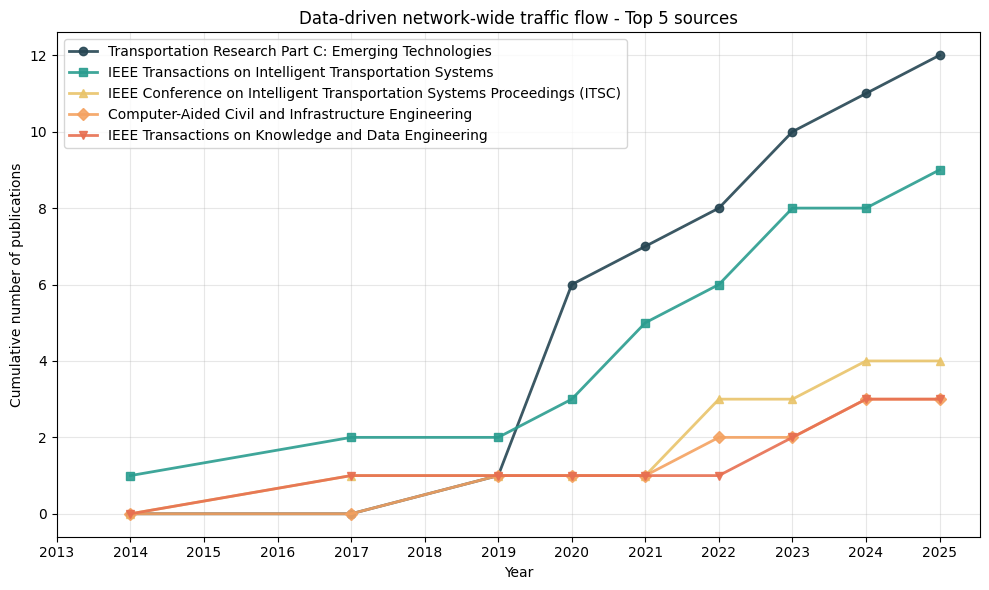

In [13]:
top_publishers = df1['Journal'].value_counts().head(5).index
df1['Year'] = df1['Year'].astype(int)
df_top = df1[df1['Journal'].isin(top_publishers)]

pub_counts = df_top.groupby(['Year', 'Journal']).size().unstack(fill_value=0)
pub_counts_cumulative = pub_counts.cumsum()
pub_counts_cumulative = pub_counts_cumulative[pub_counts_cumulative.iloc[-1].sort_values(ascending=False).index]

plt.figure(figsize=(10, 6))

for i, publisher in enumerate(pub_counts_cumulative.columns):
    plt.plot(
        pub_counts_cumulative.index,
        pub_counts_cumulative[publisher],
        marker=markers[i],                 # assign marker
        color=colors[i],              # assign color
        linewidth=2,
        markersize=6,
        alpha=0.9,
        label=publisher
    )

plt.xlabel('Year')
plt.ylabel('Cumulative number of publications')
plt.title('Data-driven network-wide traffic flow - Top 5 sources')
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.xticks(np.arange(2013, 2026, 1))
plt.show()

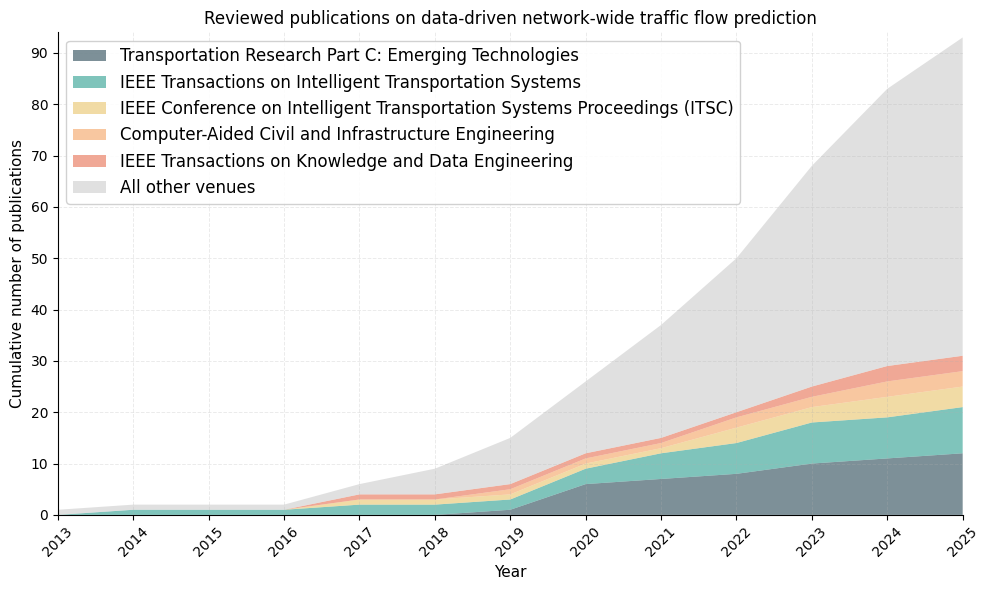

In [15]:
top_5_publishers = df1['Journal'].value_counts().head(5).index

df1['Year'] = df1['Year'].astype(int)
df1['Journal_grouped'] = df1['Journal'].apply(lambda x: x if x in top_5_publishers else 'All other venues')

pub_counts = df1.groupby(['Year', 'Journal_grouped']).size().unstack(fill_value=0)

if 'All other venues' in pub_counts.columns:
    top_5_cols = [col for col in pub_counts.columns if col != 'All other venues']
    top_5_sorted = pub_counts[top_5_cols].sum().sort_values(ascending=False).index.tolist()
    pub_counts = pub_counts[top_5_sorted + ['All other venues']]

all_years = np.arange(pub_counts.index.min(), pub_counts.index.max() + 1)
pub_counts = pub_counts.reindex(all_years, fill_value=0)

pub_counts_cumulative = pub_counts.cumsum()

max_value = pub_counts_cumulative.sum(axis=1).max()

fig, ax = plt.subplots(figsize=(10, 6))

ax.stackplot(pub_counts_cumulative.index, 
             [pub_counts_cumulative[col] for col in pub_counts_cumulative.columns],
             labels=pub_counts_cumulative.columns,
             colors=colors,
             alpha=0.6)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Cumulative number of publications', fontsize=11)
ax.set_title('Reviewed publications on data-driven network-wide traffic flow prediction', fontsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper left', framealpha=0.9, fontsize=12)

ax.set_xticks(all_years)
ax.set_xticklabels(all_years, rotation=45)
ax.set_xlim(all_years[0], all_years[-1])
ax.grid(alpha=0.25, linestyle='--', linewidth=0.7)
ax.set_yticks(range(0, int(max_value) + 1, 10))
ax.set_ylim(0, max_value + 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()